In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from rfml_uav.drone_rf.consts import BUI_dict

load_dotenv()

True

In [ ]:
# Path of raw RF data
filename = os.path.join(os.getenv("DATA_PATH"), "raw")

opt = [["Background", 0, 5], ["Bebop", 3, 10], ["Phantom", 0, 7]]
fs_t = 40e6  # Sampling frequency in MHz

In [4]:
def visualize(option):
    drone_type = option[0]
    mode = option[1]
    segment = option[2]
    x = np.loadtxt(os.path.join(filename, f"{BUI_dict[drone_type][mode]}L_{segment}.csv"), delimiter=',')
    y = np.loadtxt(os.path.join(filename, f"{BUI_dict[drone_type][mode]}H_{segment}.csv"), delimiter=',')

    # Normalize
    x = x / np.max(np.abs(x))
    y = y / np.max(np.abs(y))
    
    # Time axis
    t = np.arange(0, len(x) / fs_t, 1 / fs_t)
    
    # Plotting
    plt.figure(figsize=(8.4, 6))  # size in inches (840x600 pixels at 100 dpi)
    plt.plot(t, x, label=r'$x^{(L)}$')
    plt.plot(t, y - 2, 'r', label=r'$x^{(H)}$')
    plt.ylim([-3.1, 1.1])
    plt.grid(True, which='both')
    plt.xlabel('Time (s)', fontsize=18)
    plt.legend(loc='lower left')
    plt.xticks(fontweight='bold', fontsize=20, fontname='Times')
    plt.yticks([])  # Remove y-tick labels
    plt.title(f"Signal: {drone_type}, mode: {mode}, segment {segment}")
    plt.tight_layout()
    plt.show()

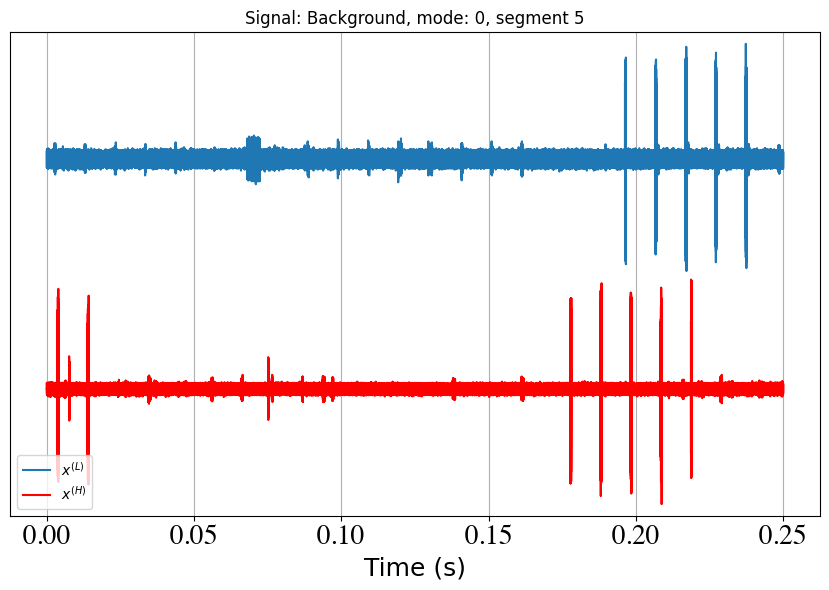

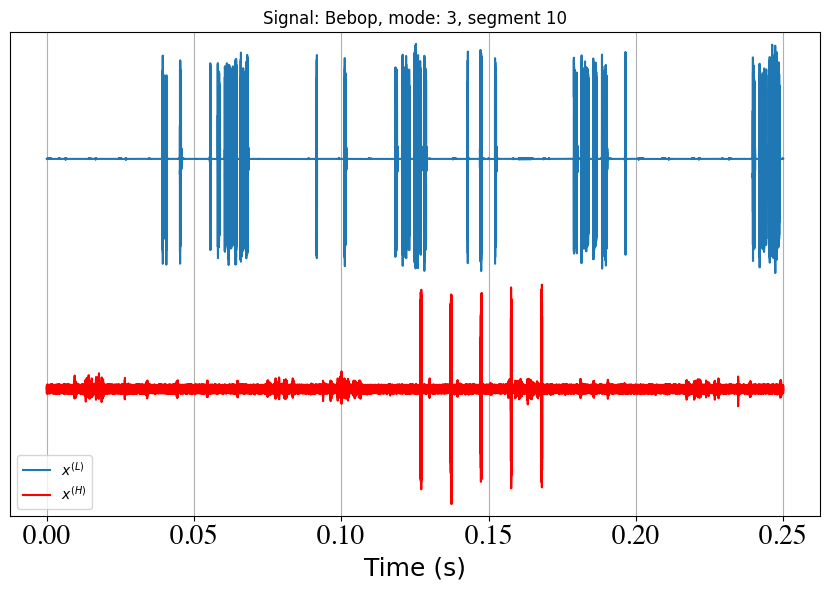

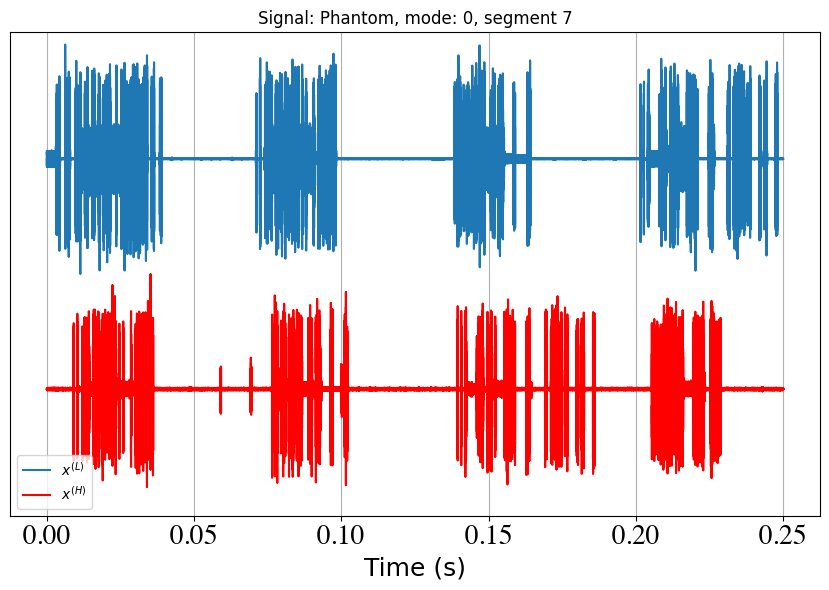

In [26]:
for i, option in enumerate(opt):
    visualize(option)

In [ ]:
save_path = os.path.join(os.getenv("DATA_PATH"), "snippets")
os.makedirs(save_path, exist_ok=True)

# Saving Option
Q = input('Do you want to save the results (Y/N)\n')
if Q.lower() == 'y':
    for i in range(3):
        plt.savefig(os.path.join(save_path, f"snippet_{i + 1}.pdf"), dpi=512)
else:
    print("Results not saved.")